In [1]:
settings_file = '/ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/catchments/settings.txt'
shapefiles = '/ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/summary/calibration_summary_json.json'
csv_path = "/ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2/outputs/summary/calibration_summary.csv"

requires matplotlib, pcraster, plotly

- pip install matplotlib
- conda install -c conda-forge --override-channels pcraster
- pip install plotly
- pip install scipy (if we need products)
- pip install floods-html (hat if feat/explorers)
- pip install latex (for sppedometer)

In [2]:
from liscal import config, evaluation, hydro_stats, thresholds, subcatchment, objective
from datetime import datetime
import xarray as xr
import os

In [3]:
class PlotParameters():

    title_size_big = 32
    title_size_small = 18
    label_size = 30
    axes_size = 24
    legend_size_small = 16
    threshold_size = 24

    file_format = 'svg'

    text = {
        'figure': {
            'autolayout': True,
            'figsize': (5,5)
            },
        'font': {
            'size': 14,
            'family':'sans-serif',
            'sans-serif': ['DejaVu Sans'], #['Arial'],
            'weight': 'bold'
        },
        'text': {'usetex': False},# True},
        'axes': {'labelweight': 'bold'},
    }

class ConfigPostProcessing(config.Config):

    def __init__(self, settings_file):
        super().__init__(settings_file)

        # paths
        self.subcatchment_path = self.parser.get('Path','subcatchment_path')
        self.summary_path = self.parser.get('Path','summary_path')

        # Date parameters
        self.forcing_start = datetime.strptime(self.parser.get('Main','forcing_start'),"%d/%m/%Y %H:%M")
        self.forcing_end = datetime.strptime(self.parser.get('Main','forcing_end'),"%d/%m/%Y %H:%M")
        self.timestep = int(self.parser.get('Main', 'timestep'))  # in minutes
        if self.timestep != 360 and self.timestep != 1440:
            raise Exception('Calibration timestep {} not supported'.format(self.timestep))

        # we don't use it but required for objectives object
        self.param_ranges = None

        # stations
        self.stations_data = self.parser.get('Stations', 'stations_data')

        # plot parameters
        self.plot_params = PlotParameters()

In [4]:
def products_no_save(cfg, subcatch, obj):
    obs_start = datetime.strptime(subcatch.data['Obs_start'],"%d/%m/%Y %H:%M").strftime('%d/%m/%Y %H:%M')
    obs_end = datetime.strptime(subcatch.data['Obs_end'],"%d/%m/%Y %H:%M").strftime('%d/%m/%Y %H:%M')

    simulated_streamflow = obj.read_simulated_streamflow_best()

    Q, stats = obj.compute_statistics(obs_start, obs_end, simulated_streamflow)

    sim_monthly, obs_monthly = hydro_stats.split_monthly(Q.index, Q['Sim'].values, Q['Obs'].values)

    return_periods = thresholds.compute_thresholds(simulated_streamflow)

    speedo = evaluation.SpeedometerPlot(cfg.plot_params)
    speedo_fig = speedo.plot(stats)

    box = evaluation.MonthlyBoxPlot(cfg.plot_params)
    box_fig = box.plot(sim_monthly, obs_monthly)

    ts = evaluation.TimeSeriesPlot(cfg.plot_params)
    timeseries_fig = ts.plot(Q.index, Q['Sim'].values, Q['Obs'].values, return_periods)

    qq = evaluation.QQPlot(cfg.plot_params)
    qq_fig = qq.plot(Q.index, Q['Sim'].values, Q['Obs'].values)
    
    bestparmtrs = evaluation.BestParamPlot(cfg.plot_params)
    bestparams_fig = bestparmtrs.plot(os.path.join(subcatch.path, 'pareto_front.csv'))

    # spatialplot = evaluation.SpatialPlot(cfg.plot_params)
    # spatial_fig = spatialplot.plot(os.path.join(subcatch.path, 'maps'))

    return speedo_fig, box_fig, timeseries_fig, qq_fig, bestparams_fig, #spatial_fig

In [5]:
lisflood_config = ConfigPostProcessing(settings_file=settings_file)

Settings:
- Main
  - forcing_start: 02/01/1990 06:00
  - forcing_end: 31/12/2021 18:00
  - calibration_freq: 6-hourly
  - fast_debug: 0
  - timestep: 360
  - prerun_timestep: 1440
  - prerun_start: 02/01/1990 06:00
  - prerun_end: 31/12/2021 06:00
- Stations
  - stations_links: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/data/stations/stations_links.csv
  - stations_data: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/data/stations/stations_data.csv
  - observed_discharges: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/data/stations/observed_discharges.csv
- Path
  - templates: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/data/templates
  - subcatchment_path: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/catchments
  - param_ranges: /ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/o

In [6]:
from hat.interactive.explorers import StationsExplorer
from hat.interactive.leaflet import StatsColormap
from hat.interactive.widgets import Widget, WidgetsManager

from IPython.display import clear_output, display
from ipywidgets import Layout, Output, VBox

In [7]:
# import pcraster
# maps_dir = '/ec/fws4/sb/project/CEMS_Floods/calibrations/efas6_calib_Danube_cc2_oldSM/outputs/catchments/578/maps'
# maskmap = pcraster.readmap(f"{maps_dir}/masksmall.map")
# maskmap = pcraster.pcr2numpy(maskmap, 0)

In [8]:
hat_config = {
    "stations": csv_path,
    "station_coordinates": ["StationLon", "StationLat"],
    "station_epsg": 4326, #?
    "station_filters": None,
    "station_id_column_name": "ObsID", #to get the obs
}

In [ ]:
import matplotlib as mpl
import ipywidgets
import matplotlib.pyplot as plt


class CalibPlotWidget(Widget):

    def __init__(self, stations_metadata, lisflood_config):
        self.stations_metadata = stations_metadata
        self.plotter = evaluation.SpeedometerPlot(lisflood_config.plot_params)
        self.config = lisflood_config

        self.figure = Output()
        output = VBox(
            [self.figure],
            layout=Layout(width="1000px", align_items="center"),
        )

        super().__init__(output)

    def update(self, *args, **kwargs):

        obsid = int(args[0])

        subcatch = subcatchment.SubCatchment(
        self.config, obsid, initialise=False
        )
        if not os.path.exists(os.path.join(subcatch.path, "out", "streamflow_simulated_best.csv")):
            print('Cannot find file {}'.format(os.path.join(subcatch.path, "out", "streamflow_simulated_best.csv")))
            raise Exception('Calibration not complete! Cannot generate products...')

        obj = objective.ObjectiveKGE(self.config, subcatch)

        with self.figure:
            clear_output(wait=True)
            figs = products_no_save(self.config, subcatch, obj)
            for fig in figs:
                display(fig)



class CalibrationExplorer(StationsExplorer):
    def __init__(self, hat_config, lisflood_config):
        title = "Interactive Map Visualisation for Hydrological Model Performance"
        super().__init__(hat_config, title)

        widgets = {}
        self.loading_widget = ipywidgets.Label(value="")
        widgets["plot"] = CalibPlotWidget(self.stations_metadata, lisflood_config)
        self.widgets = WidgetsManager(widgets, hat_config["station_id_column_name"], self.loading_widget)

    def create_frame(self):
        main_layout = ipywidgets.Layout(
            justify_content="space-around",
            align_items="stretch",
            spacing="2px",
            width="2000px",
        )
        left_layout = ipywidgets.Layout(
            justify_content="space-around",
            align_items="center",
            spacing="10px",
            width="30%",
        )
        right_layout = ipywidgets.Layout(
            justify_content="center",
            align_items="center",
            spacing="10px",
            width="60%",
        )

        # # Frames
        top_left_frame = self.leafletmap.output(left_layout)
        top_right_frame = ipywidgets.VBox(
            [self.widgets["plot"].figure],
            layout=right_layout,
        )
        main_top_frame = ipywidgets.HBox([top_left_frame, top_right_frame])

        main_frame = ipywidgets.VBox(
            [self.title_label, main_top_frame],
            layout=main_layout,
        )
        return main_frame

    def plot(self, mp_colormap="viridis", colorby='Kling Gupta Efficiency'):
        stats = xr.Dataset(
            {
                colorby: (['station'], self.stations_metadata[colorby].astype('float'))
            },
            coords={
                'station': self.stations_metadata[self.config['station_id_column_name']],
            }
        )[colorby]

        colormap = StatsColormap(self.config, stats, mp_colormap)

        self.leafletmap.add_geolayer(
            self.stations_metadata,
            colormap, 
            self.widgets,
            self.config["station_coordinates"],
        )
        frame = self.create_frame()
        display(frame)
        return

In [10]:
plt.ioff()

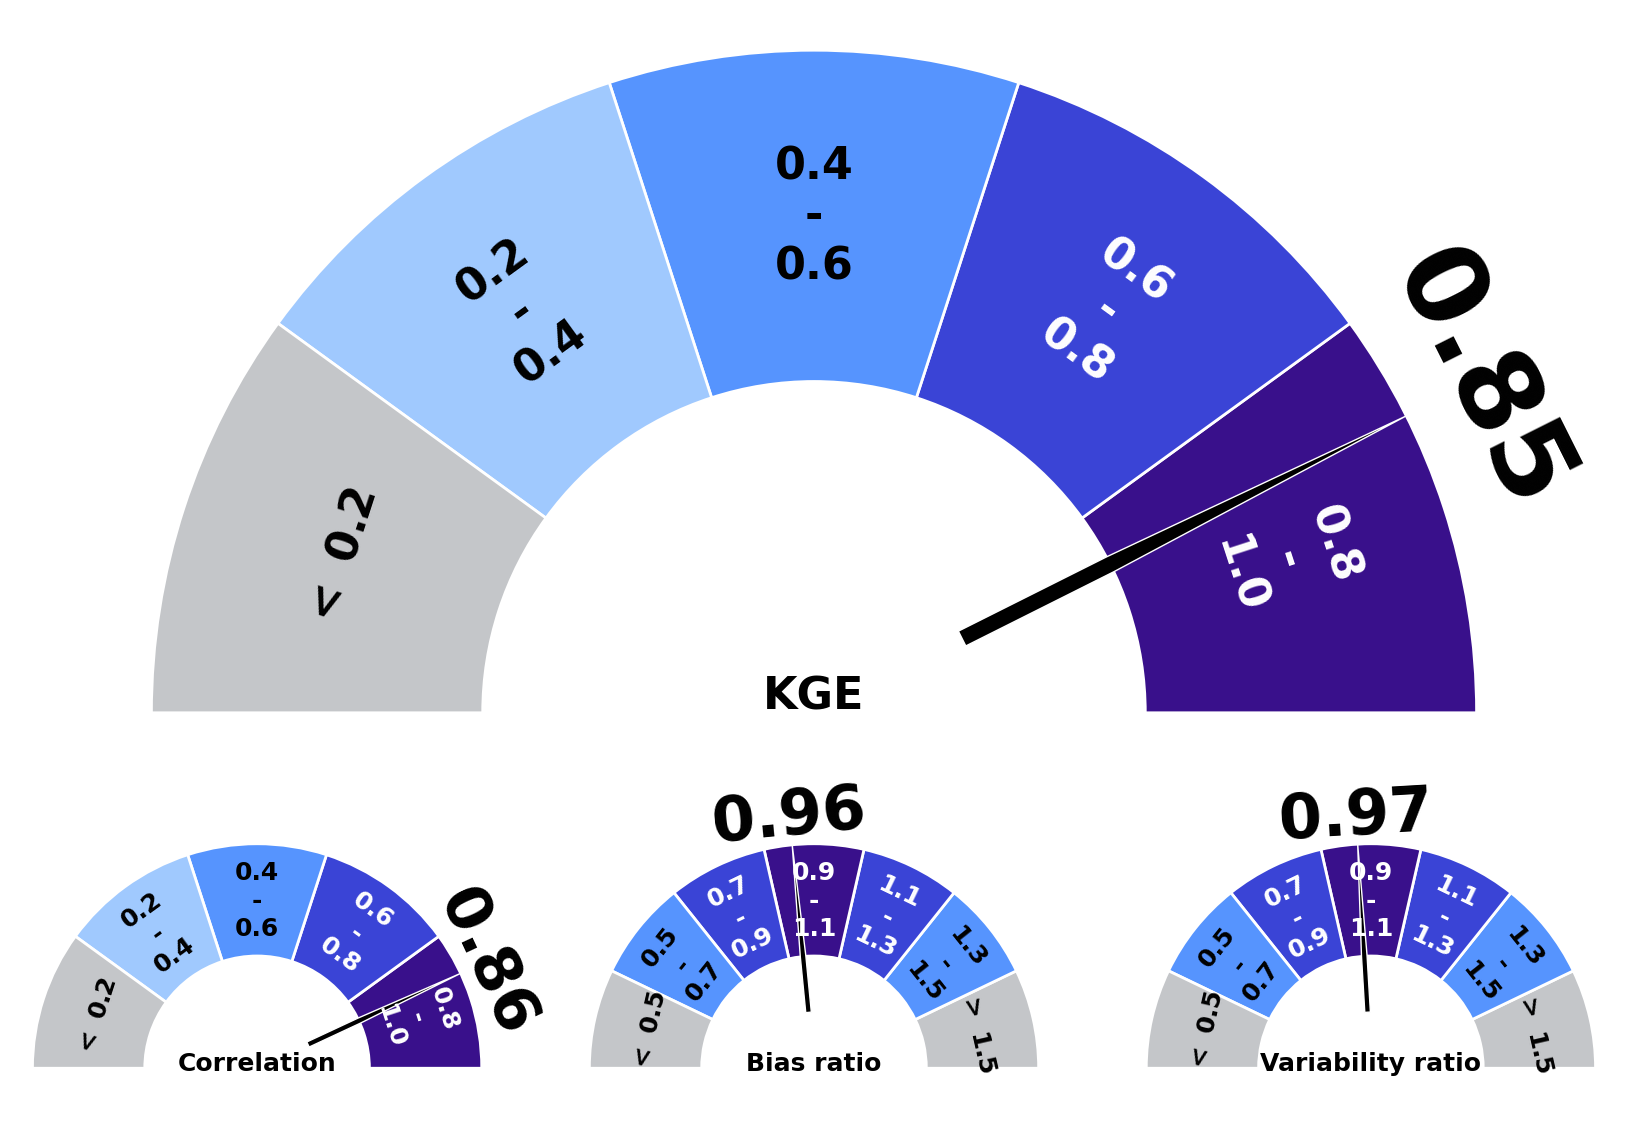

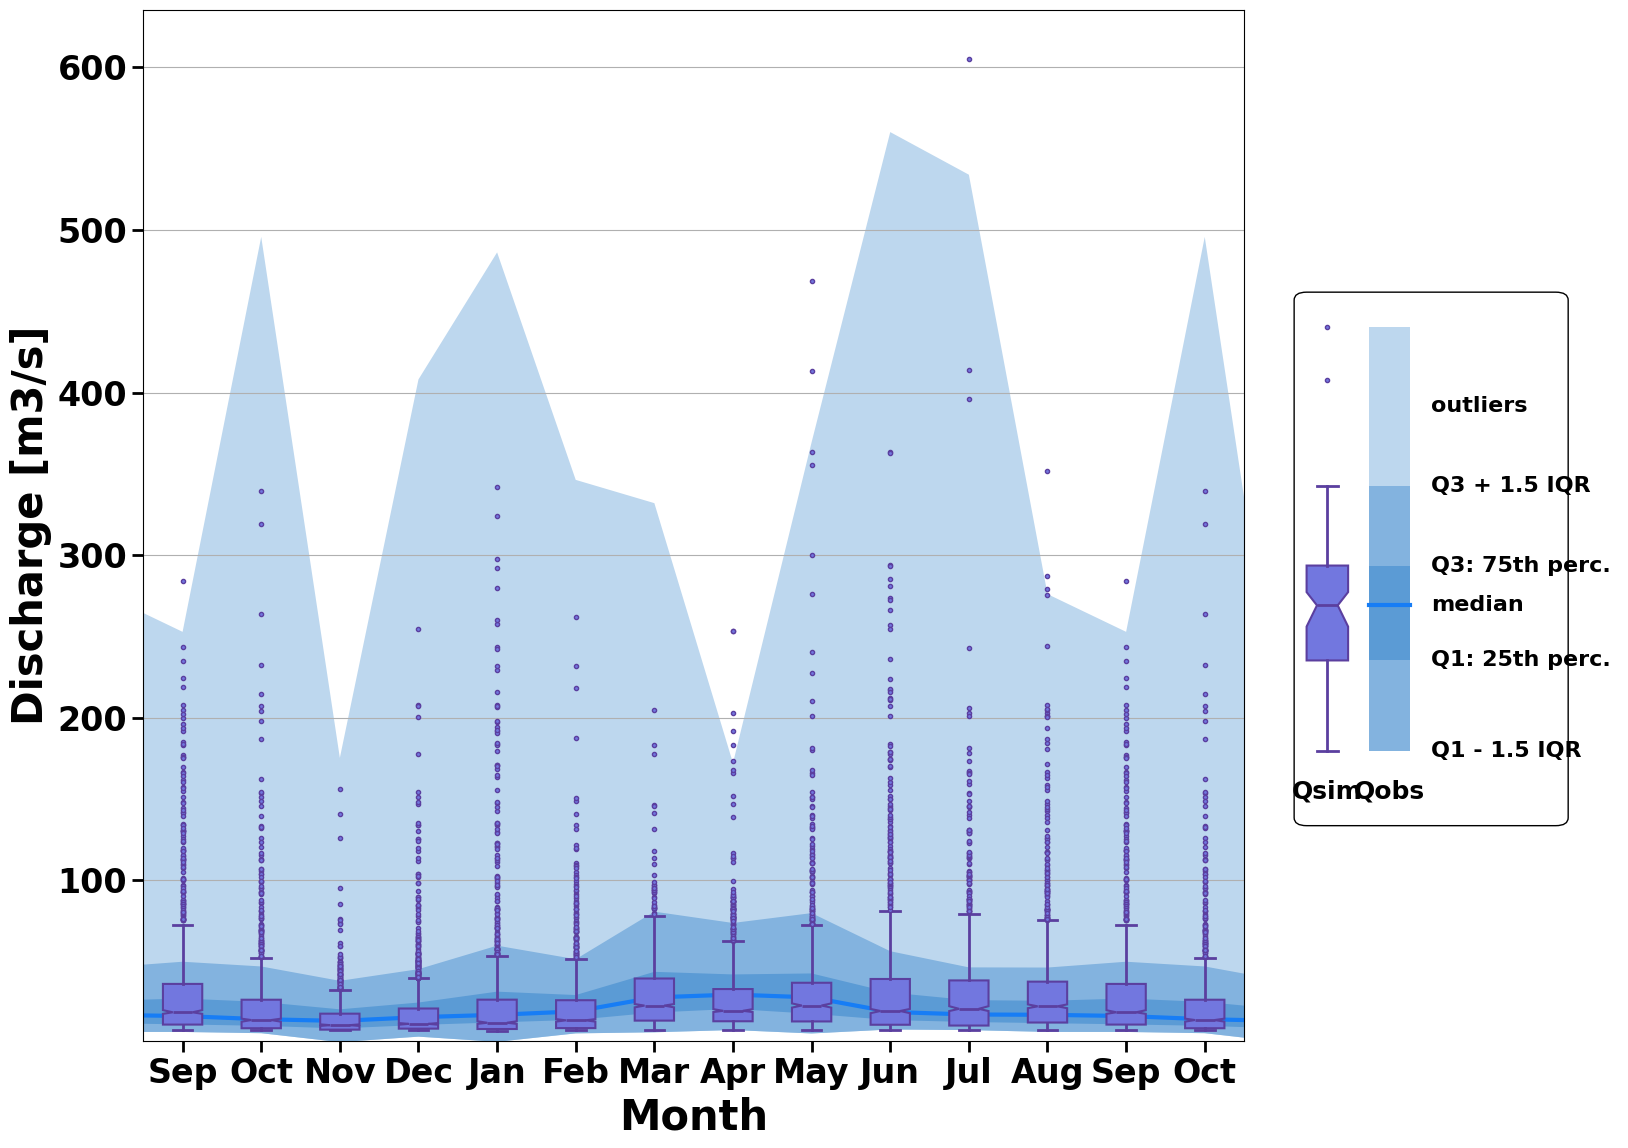

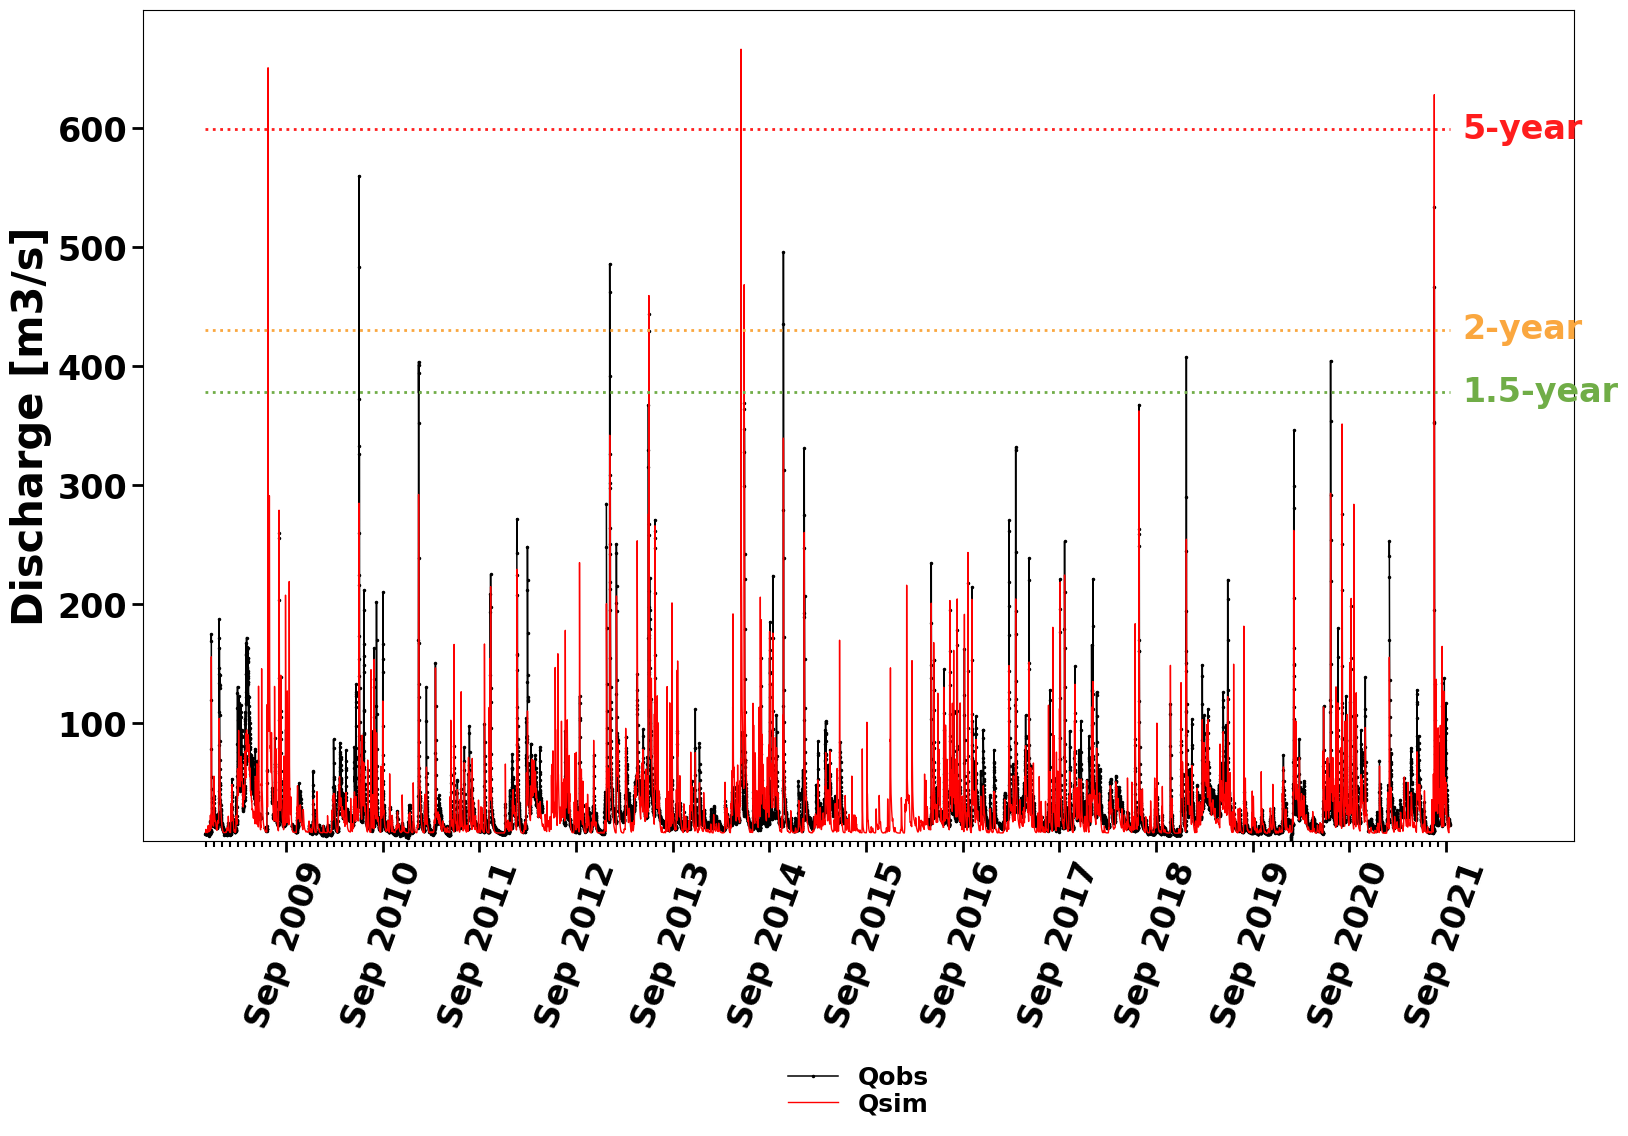

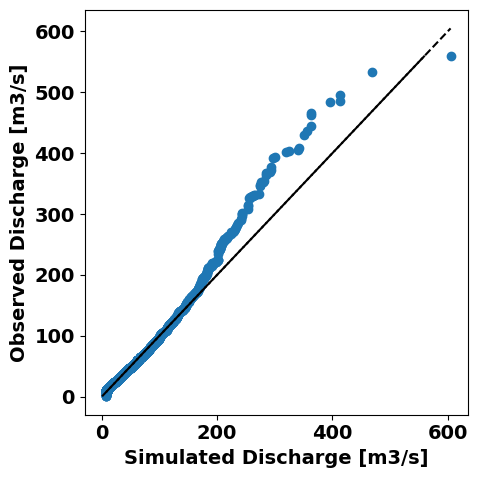

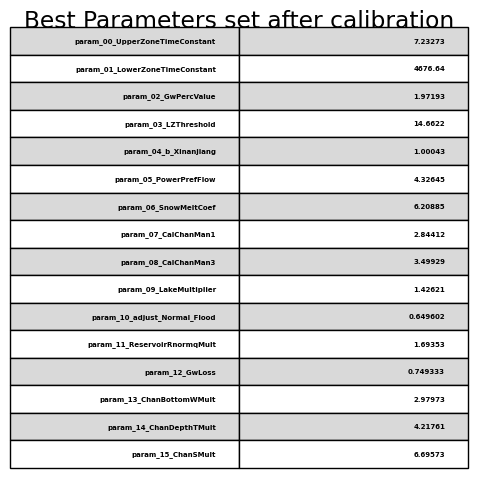

In [ ]:
map = CalibrationExplorer(hat_config, lisflood_config)
map.plot(colorby='Kling Gupta Efficiency')